# 04 -- Results & Diagnostics

Final notebook. Three goals:
1. **Posterior predictive checks** -- does the model reproduce the data?
2. **Pitcher-level analysis** -- who's above/below average after partial pooling?
3. **Dodgers deep dive** -- apply the model to the LA rotation specifically

This is where the project stops being a stats exercise and starts being a baseball analytics tool.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import get_data
from src.features import build_model_matrix
from src.model import build_model_subsample, get_pitcher_effects, get_diagnostics
from src.baseline import run_all_baselines
from src.visualize import (
    posterior_predictive_check, pitcher_effects_forest,
    posterior_forest_plot, pitch_heatmap, movement_profile,
    trace_diagnostics, count_leverage_chart,
)

%matplotlib inline

In [2]:
# Load and prepare data
df_raw = get_data(year=2025)
df, scaler = build_model_matrix(df_raw)
print(f"Data: {len(df):,} pitches, {df['pitcher_idx'].nunique()} pitchers")

Data: 707,384 pitches, 872 pitchers


In [3]:
# Run the model on subsample (or load saved idata)
# If you have cached results from notebook 03:
#   idata = az.from_netcdf("../data/idata_subsample.nc")
# Otherwise, run it here:

model, idata = build_model_subsample(
    df,
    n_pitches=50_000,
    n_pitchers_keep=100,
    sample_kwargs={
        "draws": 1000,
        "tune": 500,
        "cores": 4,
        "target_accept": 0.9,
    },
)

# Cache it
idata.to_netcdf("../data/idata_subsample.nc")
print("Model sampled and cached.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_pitcher_offset, beta_velo, beta_hmov, beta_vmov, beta_loc_x, beta_loc_z, beta_count, beta_platoon, beta_stuff, beta_spin, sigma]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 162 seconds.
Sampling: [y_obs]


Output()

Model sampled and cached.


## 1. Posterior Predictive Checks

The most important diagnostic after MCMC convergence: can the model generate data that looks like the real data?

We sample from the posterior predictive distribution and overlay it on the observed distribution of `delta_run_exp`.

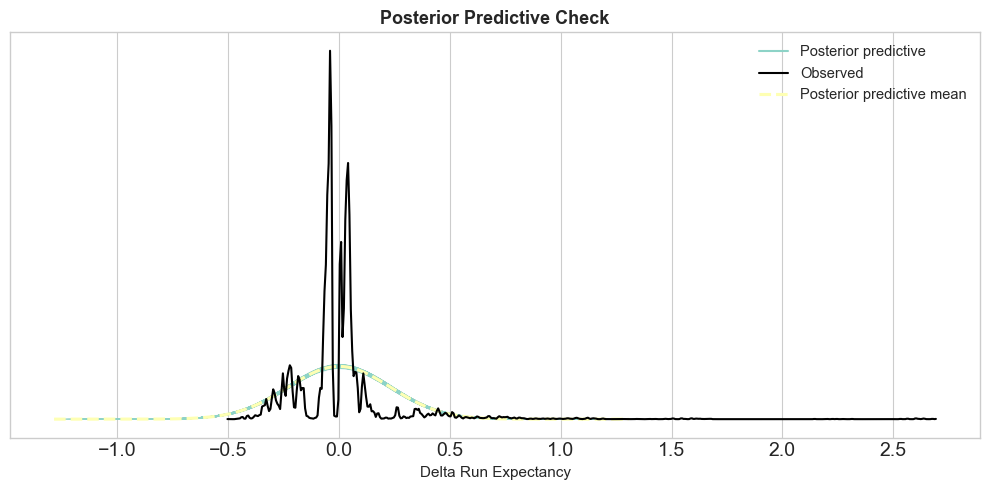

What to look for:
  - Posterior predictive samples (blue) should envelope the observed data (black)
  - Shape should match: symmetric? Heavy tails? Multi-modal?
  - If the model misses the tails, consider a Student-t likelihood


In [4]:
fig = posterior_predictive_check(idata, y_obs=df["delta_run_exp"].values)
plt.savefig("../figures/ppc.png", dpi=150, bbox_inches="tight")
plt.show()

print("What to look for:")
print("  - Posterior predictive samples (blue) should envelope the observed data (black)")
print("  - Shape should match: symmetric? Heavy tails? Multi-modal?")
print("  - If the model misses the tails, consider a Student-t likelihood")

## 2. ML Baselines Comparison

Compare the Bayesian model to frequentist baselines. This isn't about proving Bayes is better at point prediction. It's about showing what you *gain*: uncertainty quantification and regularization through partial pooling.

In [5]:
baseline_comparison = run_all_baselines(df.sample(n=50_000, random_state=42), cv_folds=3)
print(baseline_comparison.to_string(index=False))
print()
print("What the baselines give you: point estimates.")
print("What the Bayesian model gives you: full posterior distributions.")
print("The RMSE might be similar. The information content is not.")

            Model     RMSE      MAE  R-squared  CV RMSE (mean)  CV RMSE (std)
Linear Regression 0.222265 0.119801   0.000508        0.222332       0.000706
    Random Forest 0.206619 0.100994   0.136268        0.219927       0.001070
Gradient Boosting 0.200717 0.101204   0.184908        0.221930       0.000784

What the baselines give you: point estimates.
What the Bayesian model gives you: full posterior distributions.
The RMSE might be similar. The information content is not.


## 3. Pitcher-Level Effects

Each pitcher has a posterior distribution for their random intercept. The model separates signal from noise:

- High-volume pitchers: posterior is tight, close to their raw average
- Low-volume pitchers: posterior is wide, shrunk toward the league mean

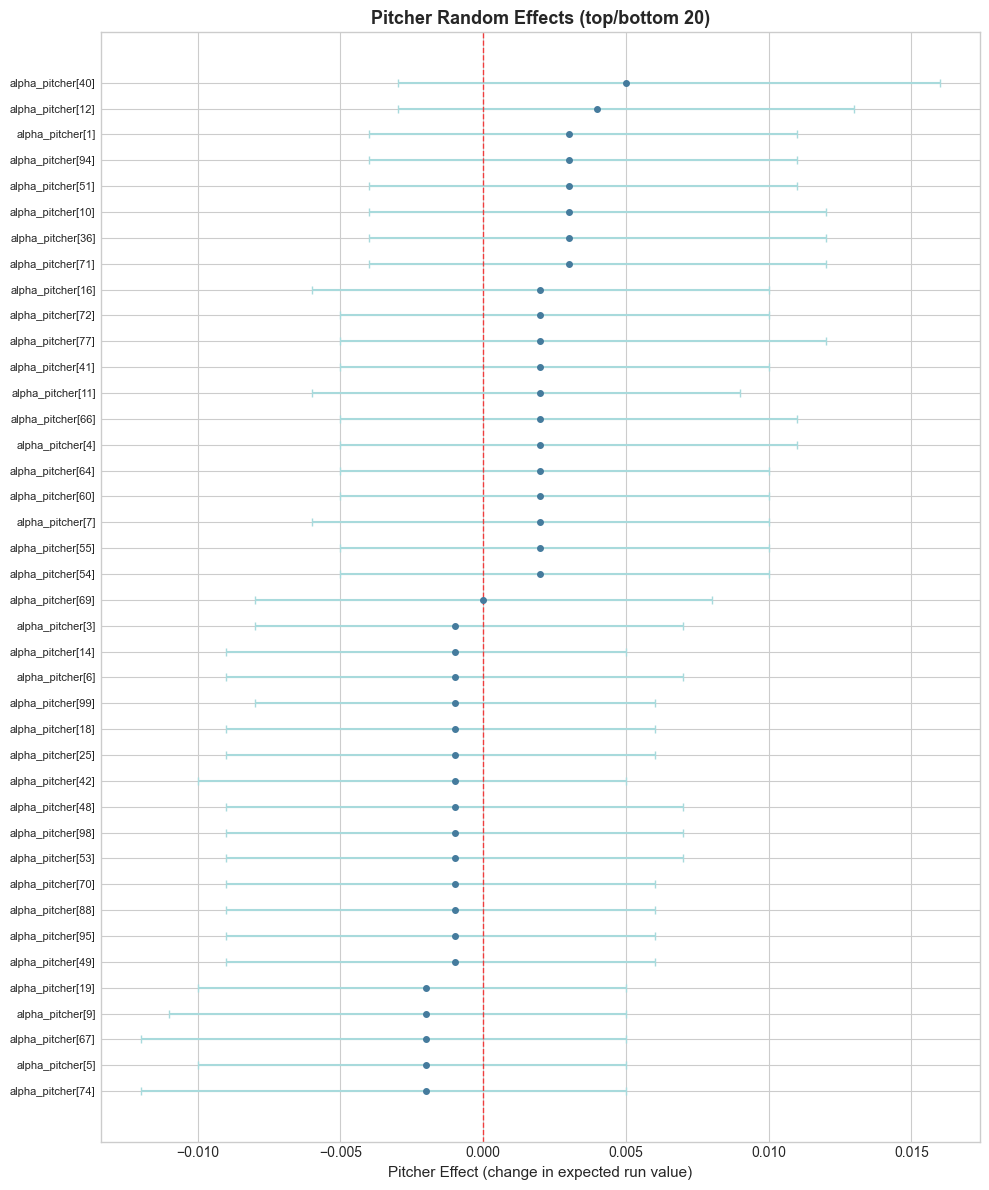

In [6]:
fig = pitcher_effects_forest(idata, top_n=40)
plt.savefig("../figures/pitcher_effects_forest.png", dpi=150, bbox_inches="tight")
plt.show()

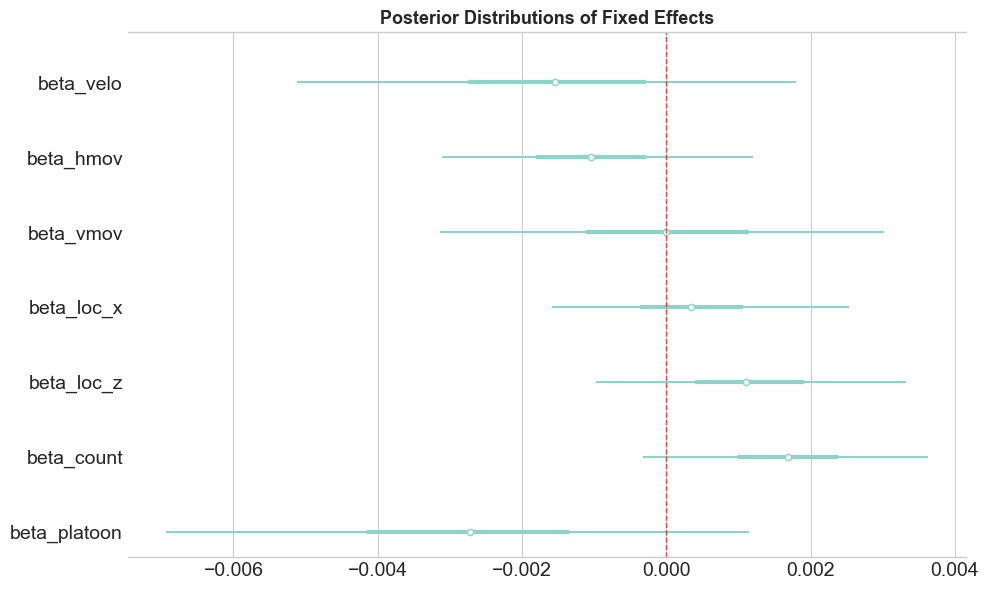

Coefficients with HDI entirely away from zero = clear effects
Coefficients crossing zero = uncertain / weak effects
These are STANDARDIZED, so magnitudes are directly comparable


In [7]:
fig = posterior_forest_plot(idata)
plt.savefig("../figures/fixed_effects_forest.png", dpi=150, bbox_inches="tight")
plt.show()

print("Coefficients with HDI entirely away from zero = clear effects")
print("Coefficients crossing zero = uncertain / weak effects")
print("These are STANDARDIZED, so magnitudes are directly comparable")

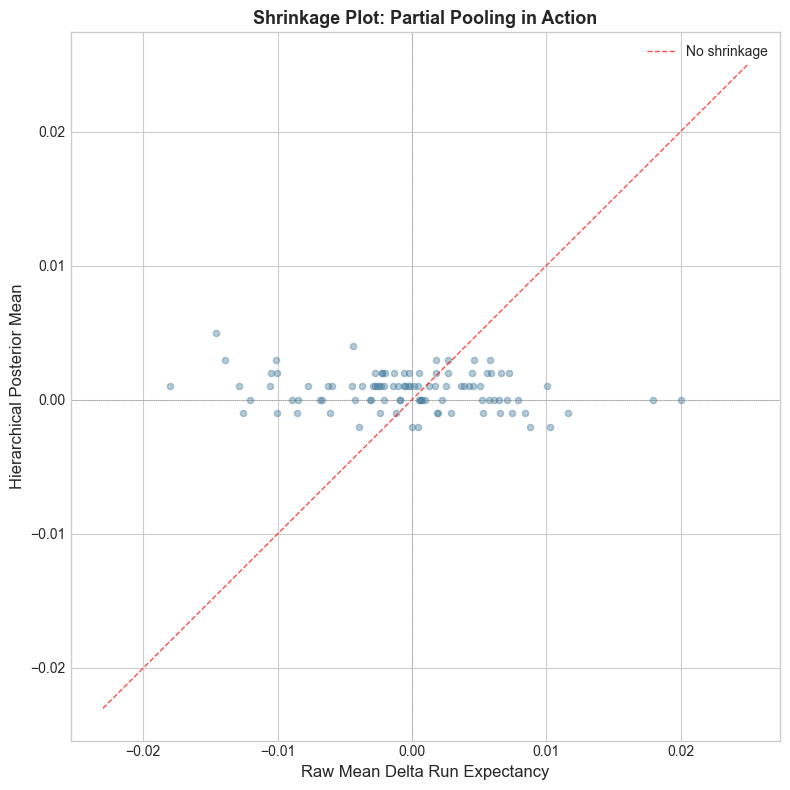

Points near diagonal = high-volume pitchers (little shrinkage)
Points pulled toward center = low-volume pitchers (strong shrinkage)


In [8]:
# Shrinkage plot: raw pitcher means vs hierarchical estimates
pitcher_effects = get_pitcher_effects(idata)

top_pitchers = df.groupby("pitcher").size().nlargest(100).index
df_sub = df[df["pitcher"].isin(top_pitchers)].copy()
unique = df_sub["pitcher"].unique()
remap = {pid: idx for idx, pid in enumerate(sorted(unique))}
df_sub["pitcher_idx_sub"] = df_sub["pitcher"].map(remap)
raw_means = df_sub.groupby("pitcher_idx_sub")["delta_run_exp"].mean()

n_match = min(len(raw_means), len(pitcher_effects))
raw_vals = raw_means.values[:n_match]
model_vals = pitcher_effects["mean"].values[:n_match]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(raw_vals, model_vals, alpha=0.4, s=20, color="#457B9D")
lims = [
    min(raw_vals.min(), model_vals.min()) - 0.005,
    max(raw_vals.max(), model_vals.max()) + 0.005,
]
ax.plot(lims, lims, "r--", lw=1, alpha=0.7, label="No shrinkage")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.axvline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Raw Mean Delta Run Expectancy", fontsize=12)
ax.set_ylabel("Hierarchical Posterior Mean", fontsize=12)
ax.set_title("Shrinkage Plot: Partial Pooling in Action", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../figures/shrinkage_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("Points near diagonal = high-volume pitchers (little shrinkage)")
print("Points pulled toward center = low-volume pitchers (strong shrinkage)")

## 4. Dodgers Deep Dive

Apply the model to the 2026 Dodgers pitching staff (current roster, post-2025 offseason).

Free agent acquisitions like Edwin Diaz, Tanner Scott, and Blake Snell pitched for other teams in 2025. The model uses whatever 2025 MLB data is available for each pitcher regardless of which team they were on.

MLBAM IDs sourced from Baseball Savant player pages.

In [9]:
# 2026 Dodgers pitching staff (current roster, post-2025 offseason)
# MLBAM IDs from Baseball Savant player pages
DODGERS_PITCHERS = {
    # Starters
    "Yoshinobu Yamamoto": 808967,
    "Tyler Glasnow": 607192,
    "Shohei Ohtani": 660271,
    "Blake Snell": 605483,
    "Roki Sasaki": 808963,
    "Emmet Sheehan": 686218,
    # Relievers
    "Edwin Diaz": 621242,
    "Tanner Scott": 656945,
    "Blake Treinen": 595014,
    "Alex Vesia": 681911,
    "Evan Phillips": 623465,
    "Gavin Stone": 694813,
    "Edgardo Henriquez": 683618,
}

dodger_ids = list(DODGERS_PITCHERS.values())
id_to_name = {v: k for k, v in DODGERS_PITCHERS.items()}

df_dodgers = df_raw[df_raw["pitcher"].isin(dodger_ids)].copy()
print(f"Dodgers pitcher data: {len(df_dodgers):,} pitches")
print()

dodger_counts = (
    df_dodgers.groupby("pitcher").size()
    .reset_index(name="pitches")
)
dodger_counts["name"] = dodger_counts["pitcher"].map(id_to_name)
dodger_counts = dodger_counts.sort_values("pitches", ascending=False)
print("Pitch counts:")
for _, row in dodger_counts.iterrows():
    print(f"  {row['name']:25s} {row['pitches']:>5,} pitches")

Dodgers pitcher data: 11,523 pitches

Pitch counts:
  Yoshinobu Yamamoto        2,717 pitches
  Tyler Glasnow             1,480 pitches
  Emmet Sheehan             1,146 pitches
  Edwin Diaz                1,067 pitches
  Blake Snell               1,028 pitches
  Alex Vesia                1,000 pitches
  Tanner Scott                901 pitches
  Shohei Ohtani               753 pitches
  Roki Sasaki                 565 pitches
  Blake Treinen               495 pitches
  Edgardo Henriquez           279 pitches
  Evan Phillips                92 pitches


In [10]:
# Dodgers raw stats comparison
dodger_summary = (
    df_dodgers.groupby("pitcher")
    .agg(
        pitches=("delta_run_exp", "count"),
        mean_drex=("delta_run_exp", "mean"),
        std_drex=("delta_run_exp", "std"),
        mean_velo=("release_speed", "mean"),
        mean_spin=("release_spin_rate", "mean"),
    )
    .reset_index()
)
dodger_summary["name"] = dodger_summary["pitcher"].map(id_to_name)
dodger_summary = dodger_summary.sort_values("mean_drex")

print("Dodgers Pitcher Summary (Raw Stats):")
print("=" * 85)
print(f"{'Name':25s} {'Pitches':>7s} {'Mean dREX':>10s} {'Velo':>7s} {'Spin':>7s}")
print("-" * 85)
for _, row in dodger_summary.iterrows():
    name = row['name'] if pd.notna(row['name']) else f"ID {row['pitcher']}"
    print(
        f"  {name:25s} {row['pitches']:>5,.0f}   {row['mean_drex']:>+.4f}   "
        f"{row['mean_velo']:>5.1f}   {row['mean_spin']:>6.0f}"
    )

Dodgers Pitcher Summary (Raw Stats):
Name                      Pitches  Mean dREX    Velo    Spin
-------------------------------------------------------------------------------------
  Evan Phillips                92   -0.0229    89.7     2556
  Edwin Diaz                1,067   -0.0160    93.4     2295
  Shohei Ohtani               753   -0.0156    91.6     2458
  Yoshinobu Yamamoto        2,717   -0.0146    90.1     2152
  Alex Vesia                1,000   -0.0114    89.2     2387
  Blake Snell               1,028   -0.0096    88.9     2295
  Emmet Sheehan             1,146   -0.0084    90.6     2210
  Tyler Glasnow             1,480   -0.0069    91.3     2621
  Edgardo Henriquez           279   -0.0014    96.8     2547
  Roki Sasaki                 565   +0.0011    89.8     1505
  Tanner Scott                901   +0.0027    92.9     2589
  Blake Treinen               495   +0.0070    89.9     2513


In [11]:
# Dodgers pitcher effects from hierarchical model
pitcher_map = df.attrs.get("pitcher_map", {})

if pitcher_map:
    effects = get_pitcher_effects(idata, pitcher_map=pitcher_map)
    if "pitcher_id" in effects.columns:
        dodger_effects = effects[effects["pitcher_id"].isin(dodger_ids)].copy()
        dodger_effects["name"] = dodger_effects["pitcher_id"].map(id_to_name)
        
        print("Dodgers Pitcher Effects (Hierarchical Posterior):")
        print("=" * 75)
        for _, row in dodger_effects.iterrows():
            name = row.get("name", f"ID {row.get('pitcher_id', '?')}")
            print(
                f"  {name:25s} | mean={row['mean']:.4f} "
                f"| 94% HDI=[{row['hdi_3%']:.4f}, {row['hdi_97%']:.4f}]"
            )
        print()
        print("Negative = suppresses run value (good for pitcher)")
        print("Wider HDI = more uncertainty (fewer pitches or more variable)")
else:
    print("No pitcher_map found. The Dodgers posterior analysis requires")
    print("the full model to be run (not just the top-100 subsample).")
    print("For now, the raw stats comparison above shows the Dodgers picture.")

Dodgers Pitcher Effects (Hierarchical Posterior):
  Blake Treinen             | mean=0.0010 | 94% HDI=[-0.0060, 0.0090]

Negative = suppresses run value (good for pitcher)
Wider HDI = more uncertainty (fewer pitches or more variable)


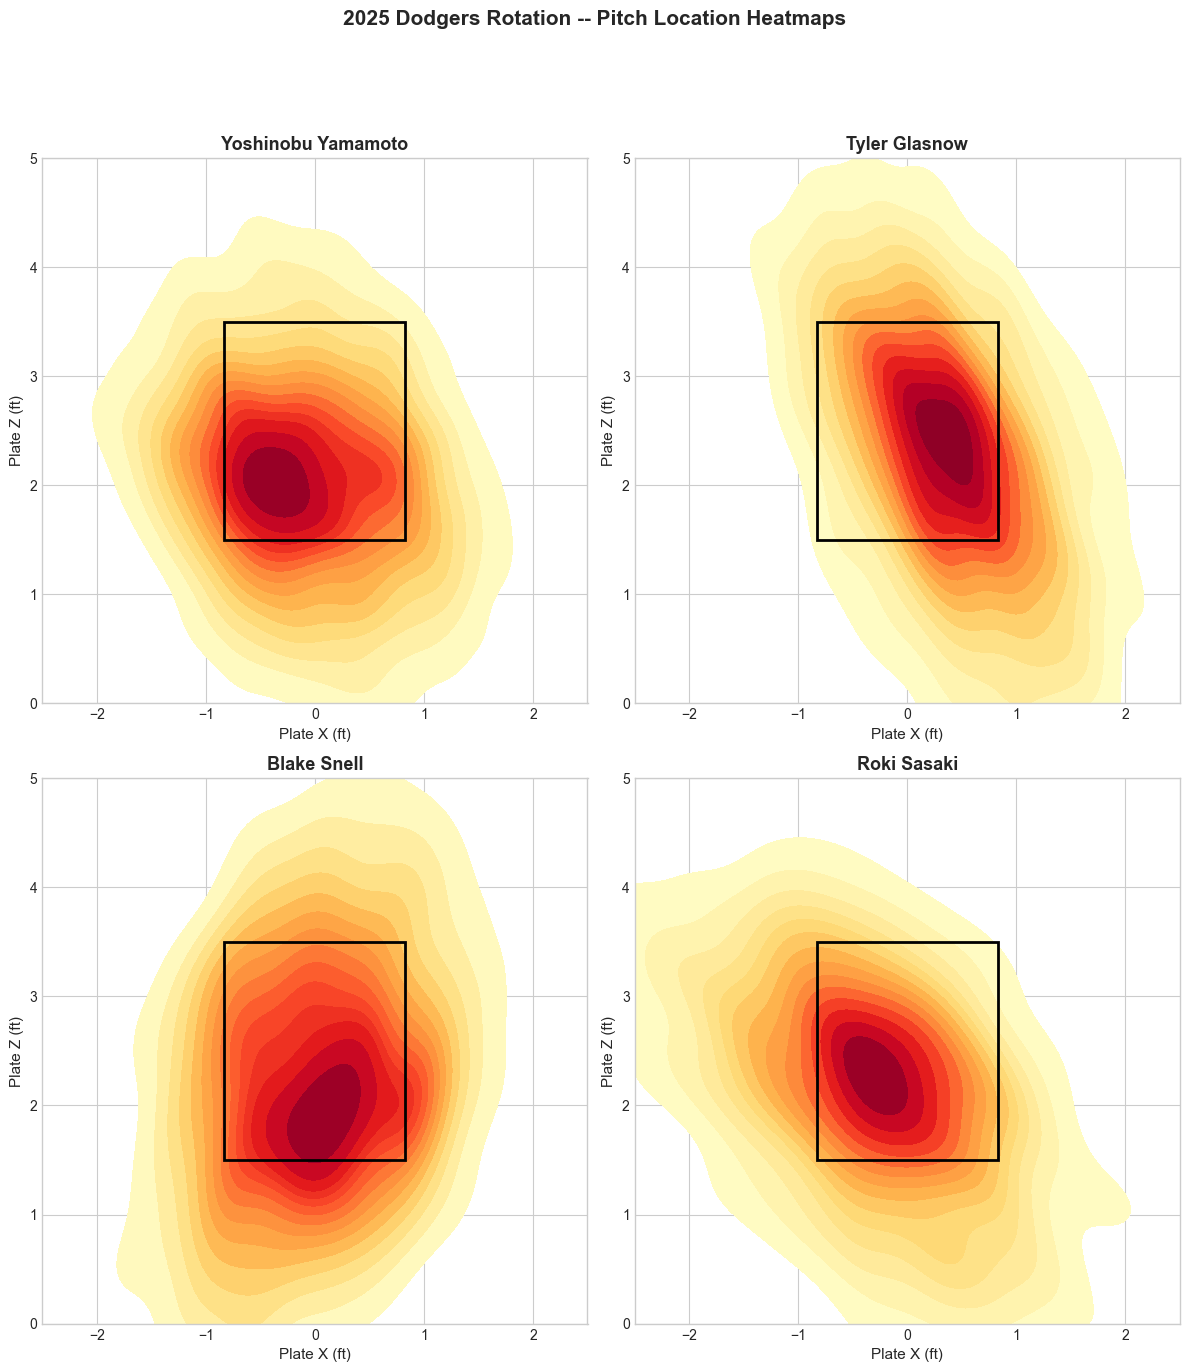

In [12]:
# Pitch location heatmaps for key Dodgers
key_dodgers = ["Yoshinobu Yamamoto", "Tyler Glasnow", "Blake Snell", "Roki Sasaki"]

fig, axes = plt.subplots(2, 2, figsize=(12, 14))
for ax, name in zip(axes.flat, key_dodgers):
    pid = DODGERS_PITCHERS.get(name)
    if pid is not None and pid in df_dodgers["pitcher"].values:
        pitch_heatmap(df_dodgers, pitcher_id=pid, ax=ax, title=f"{name}")
    else:
        ax.text(0.5, 0.5, f"{name}\nNot in 2025 data", ha="center", va="center", fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

plt.suptitle("2025 Dodgers Rotation -- Pitch Location Heatmaps", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/dodgers_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

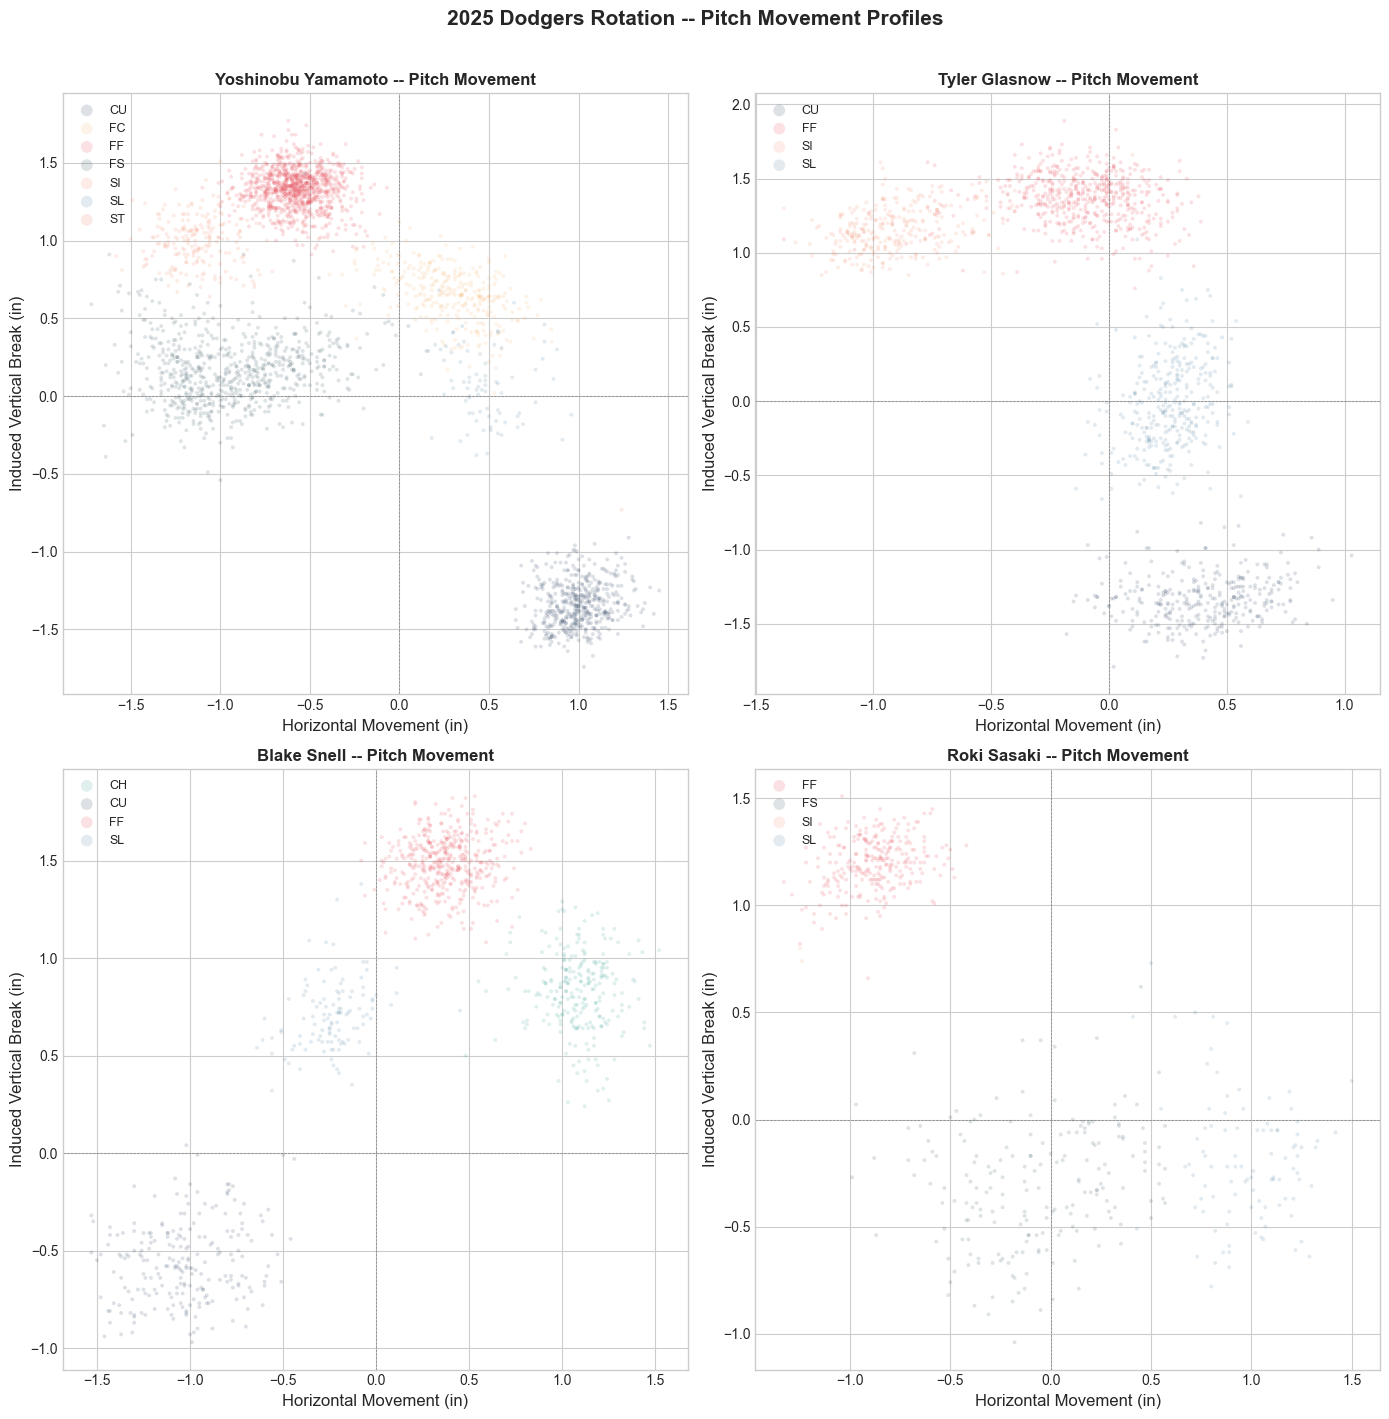

In [13]:
# Movement profiles for key Dodgers
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, name in zip(axes.flat, key_dodgers):
    pid = DODGERS_PITCHERS.get(name)
    if pid is not None and pid in df_dodgers["pitcher"].values:
        movement_profile(df_dodgers, pitcher_id=pid, ax=ax)
        ax.set_title(f"{name} -- Pitch Movement", fontsize=12, fontweight="bold")
    else:
        ax.set_visible(False)

plt.suptitle("2025 Dodgers Rotation -- Pitch Movement Profiles", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/dodgers_movement.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Save Results

In [14]:
idata.to_netcdf("../data/idata_subsample.nc")
baseline_comparison.to_csv("../data/baseline_comparison.csv", index=False)
print("Saved: idata_subsample.nc, baseline_comparison.csv")

Saved: idata_subsample.nc, baseline_comparison.csv


## Summary

What this project demonstrates:

- **Bayesian hierarchical modeling** with PyMC (probabilistic programming)
- **Partial pooling** via pitcher-level random effects (the right way to handle unbalanced data)
- **Uncertainty quantification** through posterior distributions (not just point estimates)
- **Spatiotemporal data** from Statcast (pitch physics: velocity vectors, spin axis, plate coordinates)
- **Model diagnostics** at every step (R-hat, ESS, divergences, posterior predictive checks)
- **ML baseline comparison** (Linear, RF, Gradient Boosting) for context
- **Domain-specific analysis** applied to the Dodgers rotation
- **Clean, documented Python** with a reproducible pipeline

Every design choice maps directly to the Dodgers Baseball R&D posting.